In [1]:
from pathlib import Path 
import pandas as pd
import numpy as np

data_dir = Path("../data")

df = pd.read_csv(data_dir/'clean_data.csv')

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,5577389,5,1,123,46,46,0,24.600000,23.276598,...,32,37015.0,0.0000,37015,37015,5527113.0,0.000,5527113,5527113,BENIGN
1,53469,30,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
2,53,888,2,2,62,246,31,31,31.000000,0.000000,...,32,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
3,53022,198,3,1,31,6,31,0,10.333333,17.897858,...,32,0.0,0.0000,0,0,0.0,0.000,0,0,BENIGN
4,443,116657713,24,25,1318,20487,579,0,54.916667,158.710816,...,32,330945.5,415998.6975,625101,36790,58000000.0,1250244.692,58800000,57100000,BENIGN


In [2]:
x = df.drop('Label', axis = 1)
y = df['Label']

In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y)

In [4]:
print("Train:", x_train.shape)
print("Test :", x_test.shape)

print("Train classes:")
print(y_train.value_counts())

print("\nTest classes:")
print(y_test.value_counts())

Train: (31856, 65)
Test : (7964, 65)
Train classes:
Label
DDoS                4000
DoS GoldenEye       3999
BENIGN              3973
PortScan            3892
DoS Slowhttptest    3810
DoS slowloris       3722
DoS Hulk            3181
FTP-Patator         3065
SSH-Patator         2214
Name: count, dtype: int64

Test classes:
Label
DDoS                1000
DoS GoldenEye       1000
BENIGN               993
PortScan             973
DoS Slowhttptest     953
DoS slowloris        930
DoS Hulk             796
FTP-Patator          766
SSH-Patator          553
Name: count, dtype: int64


In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    criterion='gini',
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    class_weight='balanced',
    
)

model.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42)

In [6]:
y_pred = model.predict(x_test)

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_pred, y_test)
matrix = confusion_matrix(y_pred, y_test)


print(f"accuracy --> {accuracy*100}")
print(f"confusion --> \n {matrix}")

accuracy --> 99.54796584630839
confusion --> 
 [[975   0   0   2   0   3   0   0   0]
 [  0 999   0   0   0   0   0   0   0]
 [  1   0 998   1   1   0   0   0   0]
 [  3   1   0 791   0   0   0   0   0]
 [  7   0   1   2 951   3   0   0   0]
 [  4   0   1   0   1 924   0   0   0]
 [  1   0   0   0   0   0 766   1   0]
 [  1   0   0   0   0   0   0 971   0]
 [  1   0   0   0   0   0   0   1 553]]


In [8]:
report = classification_report(
    y_test,
    y_pred,
    target_names=model.classes_,
    digits=4
)

print(report)

                  precision    recall  f1-score   support

          BENIGN     0.9949    0.9819    0.9883       993
            DDoS     1.0000    0.9990    0.9995      1000
   DoS GoldenEye     0.9970    0.9980    0.9975      1000
        DoS Hulk     0.9950    0.9937    0.9943       796
DoS Slowhttptest     0.9865    0.9979    0.9922       953
   DoS slowloris     0.9935    0.9935    0.9935       930
     FTP-Patator     0.9974    1.0000    0.9987       766
        PortScan     0.9990    0.9979    0.9985       973
     SSH-Patator     0.9964    1.0000    0.9982       553

        accuracy                         0.9955      7964
       macro avg     0.9955    0.9958    0.9956      7964
    weighted avg     0.9955    0.9955    0.9955      7964



In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(importance.head(20))

Destination Port          0.253844
Bwd Packets/s             0.118779
min_seg_size_forward      0.080226
Fwd Packet Length Max     0.071359
Bwd IAT Mean              0.069018
Bwd Packet Length Max     0.066042
Active Min                0.059869
Flow IAT Std              0.049945
Bwd Packet Length Std     0.049625
PSH Flag Count            0.036292
Subflow Fwd Bytes         0.035214
Idle Mean                 0.026751
Packet Length Std         0.017316
Average Packet Size       0.016429
Avg Bwd Segment Size      0.009657
Packet Length Variance    0.006419
Fwd Packets/s             0.005748
Fwd PSH Flags             0.003846
Fwd Packet Length Std     0.003448
Init_Win_bytes_forward    0.002832
dtype: float64


In [10]:
print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Tree depth: 20
Number of leaves: 177


In [11]:
print("Train accuracy:",
      accuracy_score(y_train, model.predict(x_train)))

print("Test accuracy:",
      accuracy_score(y_test, y_pred))

Train accuracy: 0.9973631341034656
Test accuracy: 0.9954796584630838


In [12]:
from sklearn.metrics import f1_score

macro_f1 = f1_score( y_test, y_pred, average='macro')
weighted_f1 = f1_score( y_test, y_pred, average='weighted')

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.9956399127196391
Weighted F1: 0.9954756116934276


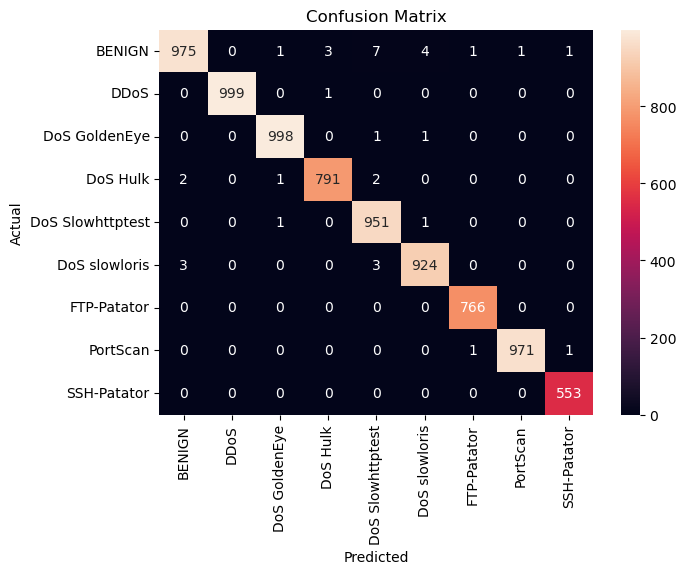

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

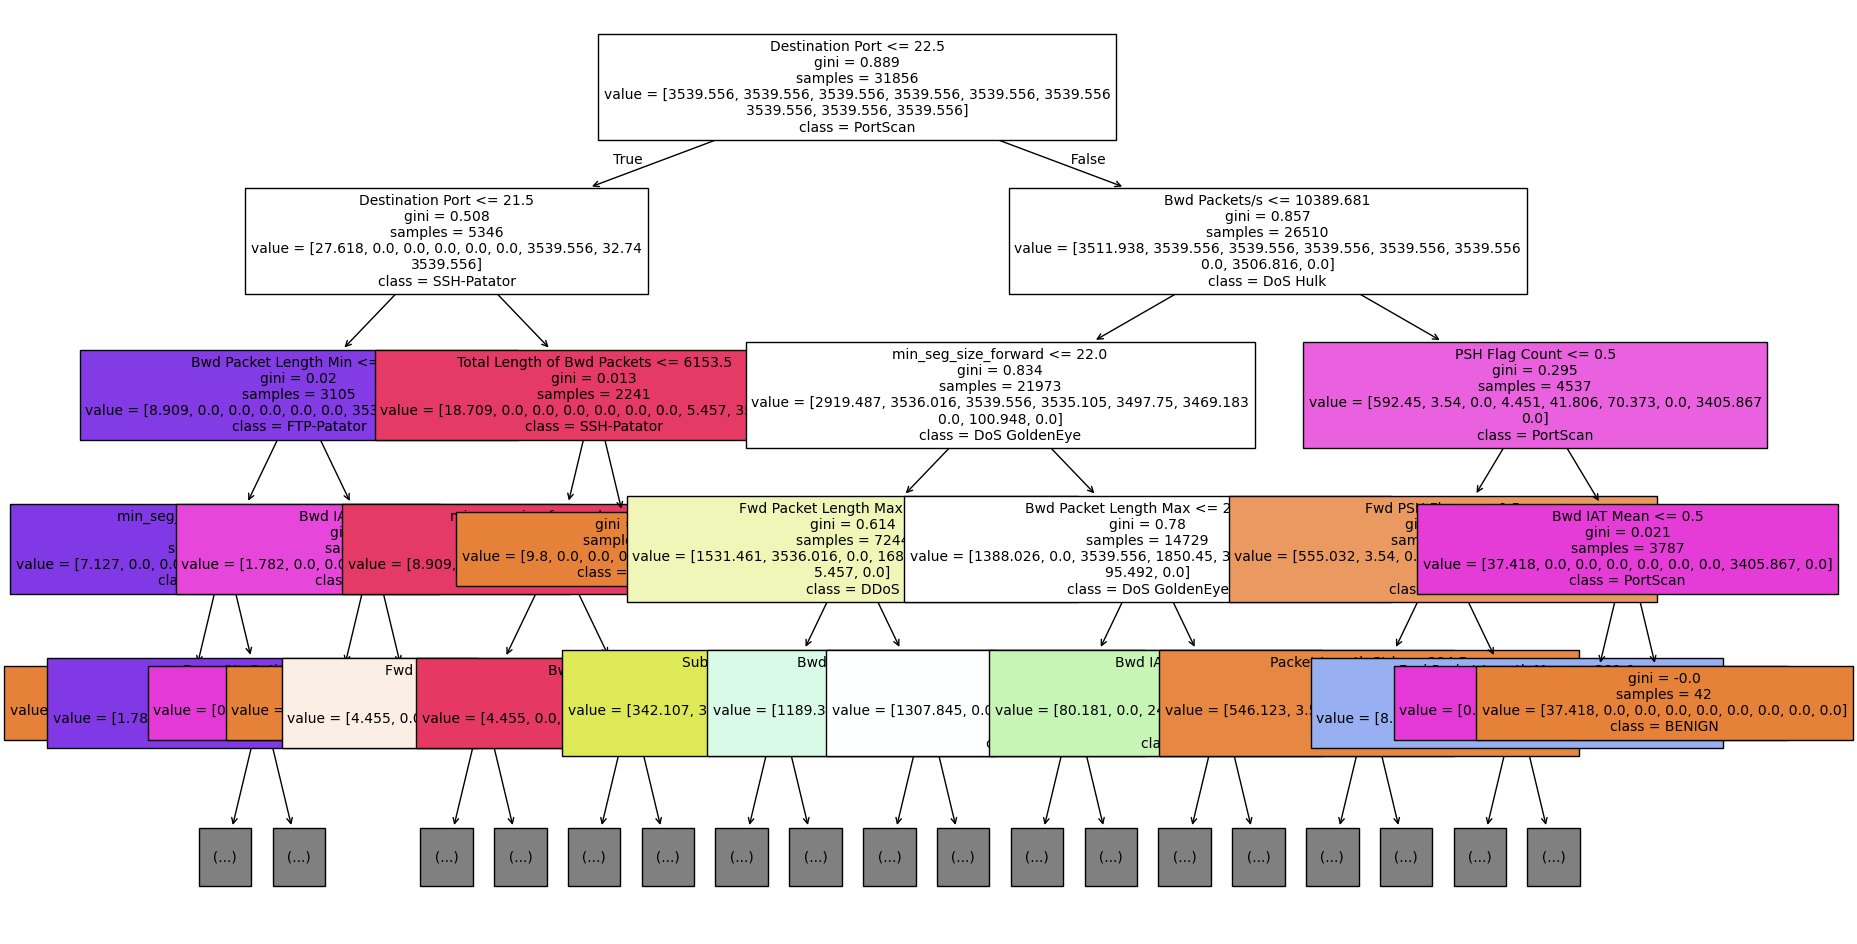

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True,
    fontsize = 10,
    max_depth = 4
)

plt.show()

# randomisedseachCV and gridSearchCV


In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)

param_dist = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth':[5, 10, 15, 20, 25, 30, None],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf':[1, 2, 5, 10],
    'class_weight':[None, 'balanced'],
    'max_features':[None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    model,
    param_distributions = param_dist,
    n_iter = 30,
    cv = 5,
    scoring = 'f1_micro',
    random_state = 42,
    n_jobs = -1
)

random_search.fit(x_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV Score:")
print(random_search.best_score_)

Best Parameters:
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': None}
Best CV Score:
0.9963272057363664


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score:
0.9967484825191455


In [40]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

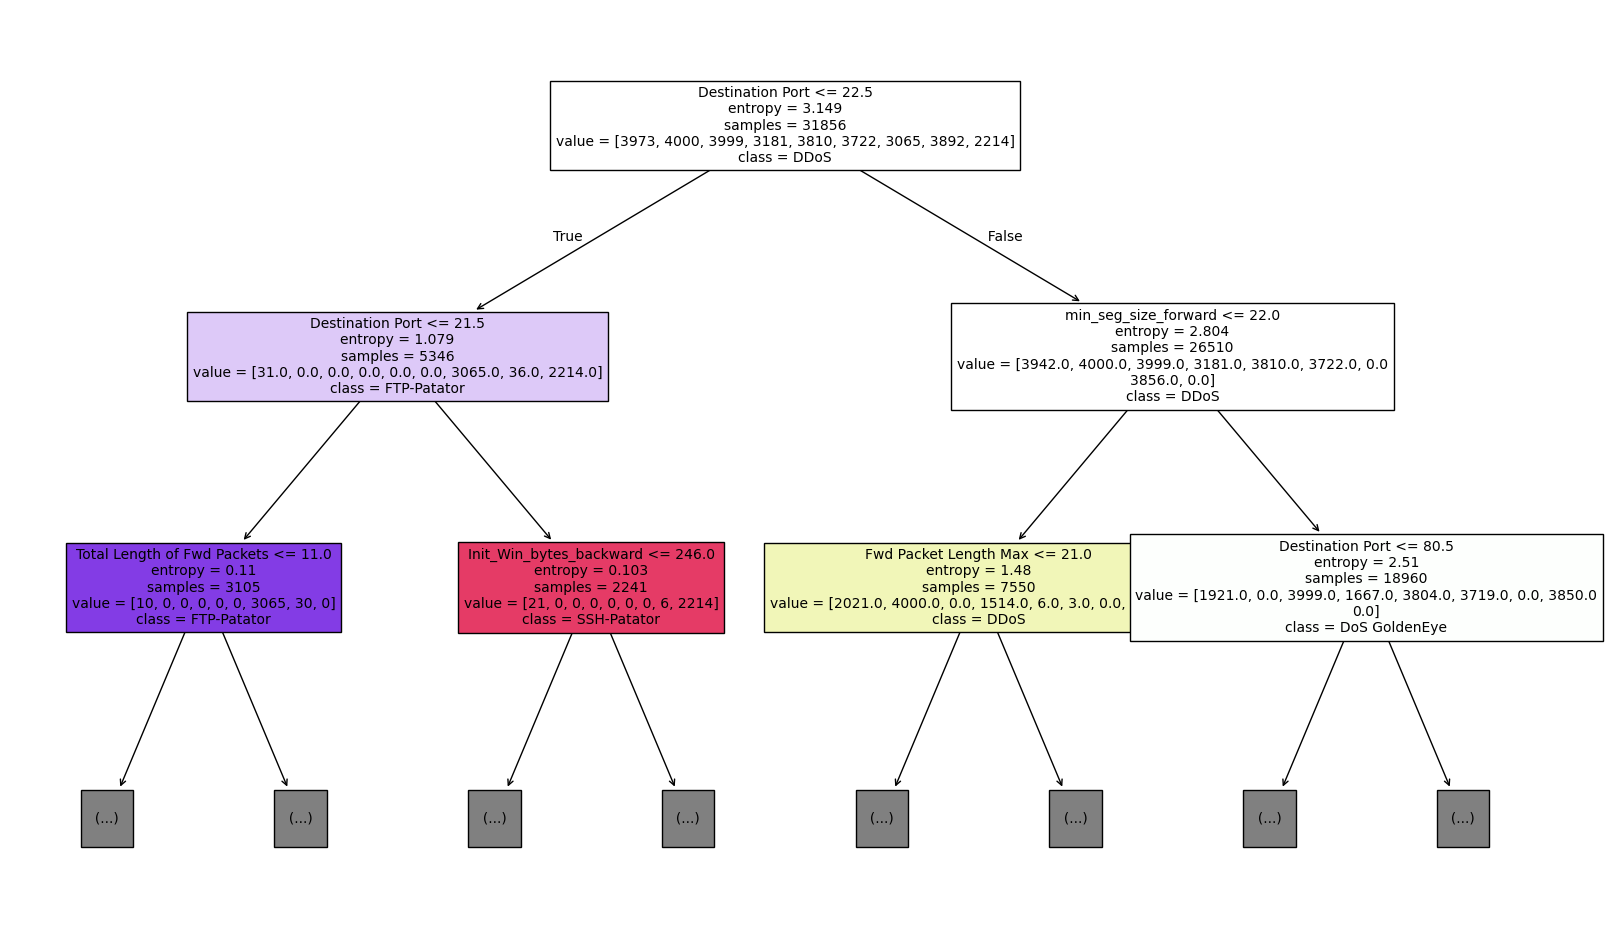

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))

plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=best_model.classes_,
    filled=True,
    fontsize = 10,
    max_depth = 2
)

plt.show()

In [41]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_pred, y_test)
report = classification_report(
    y_test,
    y_pred,
    target_names=grid_search.classes_,
    digits=4
)

print(acc)
print(report)

0.9969864389753893
                  precision    recall  f1-score   support

          BENIGN     0.9990    0.9879    0.9934       993
            DDoS     0.9990    0.9990    0.9990      1000
   DoS GoldenEye     0.9970    0.9990    0.9980      1000
        DoS Hulk     0.9987    0.9962    0.9975       796
DoS Slowhttptest     0.9937    0.9979    0.9958       953
   DoS slowloris     0.9925    0.9957    0.9941       930
     FTP-Patator     0.9974    1.0000    0.9987       766
        PortScan     0.9979    0.9990    0.9985       973
     SSH-Patator     0.9982    1.0000    0.9991       553

        accuracy                         0.9970      7964
       macro avg     0.9971    0.9972    0.9971      7964
    weighted avg     0.9970    0.9970    0.9970      7964



In [39]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_pred, y_test)
report = classification_report(
    y_test,
    y_pred,
    target_names=random_search.classes_,
    digits=4
)

print(acc)
print(report)

0.9968608739326972
                  precision    recall  f1-score   support

          BENIGN     0.9970    0.9909    0.9939       993
            DDoS     0.9990    0.9990    0.9990      1000
   DoS GoldenEye     0.9980    0.9990    0.9985      1000
        DoS Hulk     0.9987    0.9937    0.9962       796
DoS Slowhttptest     0.9896    0.9979    0.9937       953
   DoS slowloris     0.9968    0.9935    0.9952       930
     FTP-Patator     0.9974    1.0000    0.9987       766
        PortScan     0.9979    0.9990    0.9985       973
     SSH-Patator     0.9982    1.0000    0.9991       553

        accuracy                         0.9969      7964
       macro avg     0.9970    0.9970    0.9970      7964
    weighted avg     0.9969    0.9969    0.9969      7964



## Model Performance Comparison

Three Decision Tree models were evaluated on the same test dataset.

| Model | Accuracy | Macro F1-Score | Weighted F1-Score |
|---|---:|---:|---:|
| Simple Decision Tree | 99.55% | 99.56% | 99.55% |
| RandomizedSearchCV | 99.69% | 99.70% | 99.69% |
| GridSearchCV | 99.70% | 99.71% | 99.70% |

### Classification Report

#### 1. Simple Decision Tree

| Class | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| BENIGN | 99.49% | 98.19% | 98.83% |
| DDoS | 100.00% | 99.90% | 99.95% |
| DoS GoldenEye | 99.70% | 99.80% | 99.75% |
| DoS Hulk | 99.50% | 99.37% | 99.43% |
| DoS Slowhttptest | 98.65% | 99.79% | 99.22% |
| DoS slowloris | 99.35% | 99.35% | 99.35% |
| FTP-Patator | 99.74% | 100.00% | 99.87% |
| PortScan | 99.90% | 99.79% | 99.85% |
| SSH-Patator | 99.64% | 100.00% | 99.82% |

#### 2. RandomizedSearchCV

| Class | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| BENIGN | 99.70% | 99.09% | 99.39% |
| DDoS | 99.90% | 99.90% | 99.90% |
| DoS GoldenEye | 99.80% | 99.90% | 99.85% |
| DoS Hulk | 99.87% | 99.37% | 99.62% |
| DoS Slowhttptest | 98.96% | 99.79% | 99.37% |
| DoS slowloris | 99.68% | 99.35% | 99.52% |
| FTP-Patator | 99.74% | 100.00% | 99.87% |
| PortScan | 99.79% | 99.90% | 99.85% |
| SSH-Patator | 99.82% | 100.00% | 99.91% |

#### 3. GridSearchCV

| Class | Precision | Recall | F1-Score |
|---|---:|---:|---:|
| BENIGN | 99.90% | 98.79% | 99.34% |
| DDoS | 99.90% | 99.90% | 99.90% |
| DoS GoldenEye | 99.70% | 99.90% | 99.80% |
| DoS Hulk | 99.87% | 99.62% | 99.75% |
| DoS Slowhttptest | 99.37% | 99.79% | 99.58% |
| DoS slowloris | 99.25% | 99.57% | 99.41% |
| FTP-Patator | 99.74% | 100.00% | 99.87% |
| PortScan | 99.79% | 99.90% | 99.85% |
| SSH-Patator | 99.82% | 100.00% | 99.91% |

### Summary

The three models achieved very similar results on the test set. Hyperparameter tuning using RandomizedSearchCV and GridSearchCV produced small improvements compared with the basic Decision Tree.

The evaluation shows that the model performs consistently across the attack classes, with high precision, recall, and F1-scores.